# Thresholds maps
Quick notebook to generate threshold maps for presentation

In [26]:
import geopandas as gpd
import sbtn_leaf.map_plotting as mp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [22]:
NE_CRS = "+proj=natearth"
soc_q_breaks = [0,10,30,50,70,90,110,200]
se_q_breaks =  [0, 1.0, 3.0, 5.0, 10.0, 20.0, 50.0]
soc_q_pct_breaks = [-50, -25, - 10, -5, 0, 5, 10, 25, 50]

PAPER_CMAP = "RdYlGn"
PAPER_CMAP_REV = "RdYlGn_r"
PAPER_CMAP_2 = "bwr"

## Data

In [12]:
er_shp = gpd.read_file("../data/Ecoregions2017/Ecoregions2017.shp")
soc_th_vals = pd.read_csv("SOC_TH.csv")

In [50]:
soc_leaf_vals = pd.read_csv("../LEAFs/SOC/SOC_2030_ecoregions_v1.0.csv")

In [ ]:
soc_leaf_vals = soc_leaf_vals[soc_leaf_vals["variable"]=="leaf"]
soc_leaf_vals = soc_leaf_vals[["ECO_ID", "flow_name", "value"]].rename(columns={"value":"leaf"})

Data massaging

In [35]:
er_shp = er_shp.to_crs(NE_CRS)

In [36]:
soc_th_vals = soc_th_vals.rename(columns={"ECO ID": "ECO_ID", "Ecoregion name": "ECO_NAME"})

In [37]:
th_shp = er_shp.merge(soc_th_vals, how="left", on="ECO_ID")

In [38]:
th_shp.loc[
    (th_shp["Threshold"].isna()) | (th_shp["Ecoregion baseline"].isna()),
    "Threshold exceedance"
] = np.nan

In [39]:
th_shp["Threshold exceedance"] = th_shp["Threshold exceedance"].astype("Float32")

In [56]:
all_shp = th_shp.merge(soc_leaf_vals, how="left", on="ECO_ID")

### LEAFs

In [82]:
palm_oil = all_shp[all_shp["flow_name"]== "Oil palm_rf_2030y_SOC"]

Categorizing according to LEAF and Threshold Exceedance

In [83]:
palm_oil["LEAF_Ex"] = palm_oil["Threshold"] - palm_oil["leaf"]

c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [84]:
palm_oil["LEAF_Th_Category"] = np.where(
    palm_oil["LEAF_Ex"] > 0,
    "Y",
    "N"
)

c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [85]:
category_conditions = [
    (palm_oil["LEAF_Th_Category"] == "Y") &
    (palm_oil["Threshold met or exceeded? (Y/N)"] == "Y"),

    (palm_oil["LEAF_Th_Category"] == "Y") &
    (palm_oil["Threshold met or exceeded? (Y/N)"] == "N"),

    (palm_oil["LEAF_Th_Category"] == "N") &
    (palm_oil["Threshold met or exceeded? (Y/N)"] == "Y"),
]

er_categories = [1, 2, 3]

In [86]:
palm_oil['Cat'] = np.select(
    category_conditions,
    er_categories,
    default=4
)

c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


There can be no priority if leaf is non existence, as it cannot be produced

In [87]:
palm_oil.loc[
    palm_oil['leaf'].isna(),
    'Cat'
] = np.nan

## Plotting

SOC Thresholds

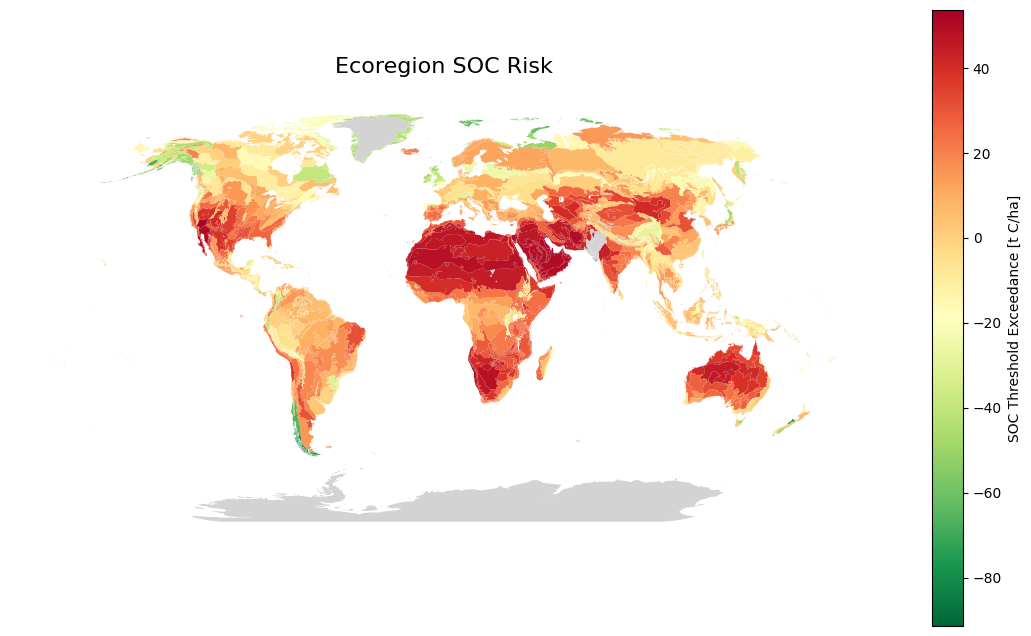

In [97]:
fig, ax = plt.subplots(figsize=(14, 8))

th_shp.plot(
    ax=ax,
    column="Threshold exceedance",
    cmap=PAPER_CMAP_REV,
    legend=True,
    legend_kwds={"label": "SOC Threshold Exceedance [t C/ha]"},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Ecoregion SOC Risk", fontsize=16, pad=15)
ax.set_axis_off()
plt.show()

Palm oil LEAFs

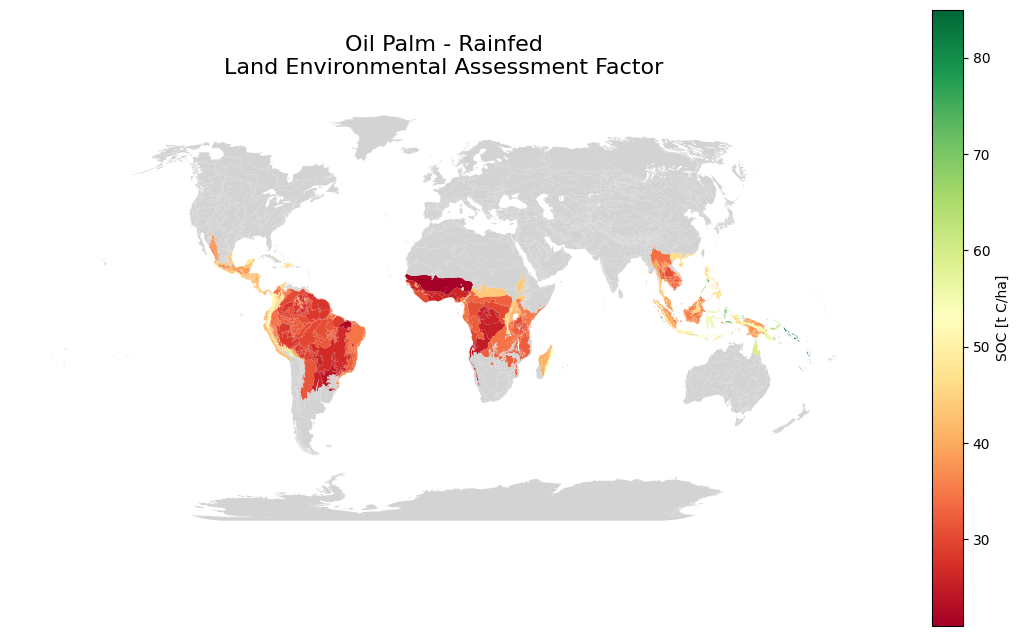

In [98]:
fig, ax = plt.subplots(figsize=(14, 8))

palm_oil.plot(
    ax=ax,
    column="leaf",
    cmap=PAPER_CMAP,
    legend=True,
    legend_kwds={"label": "SOC [t C/ha]"},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Oil Palm - Rainfed\nLand Environmental Assessment Factor", fontsize=16, pad=15)
ax.set_axis_off()
plt.show()

Ecoregion Categorization

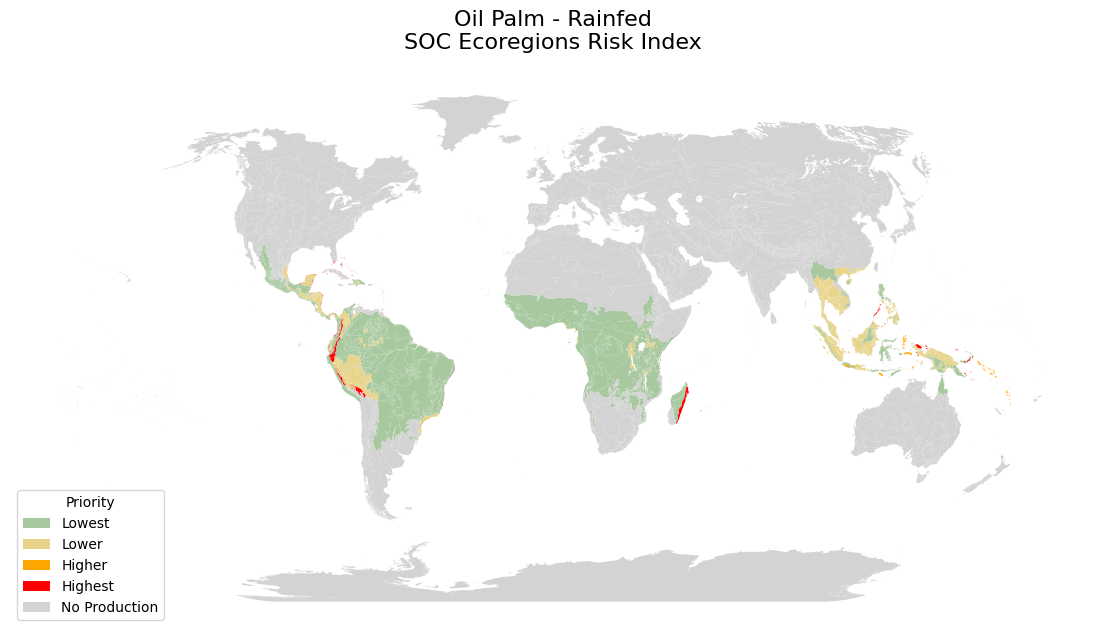

In [100]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Order matters: geopandas assigns colors to sorted unique values (1,2,3,4)
cmap = ListedColormap(['#A8C9A0', '#E8D48A', 'orange', 'red'])

fig, ax = plt.subplots(figsize=(14, 8))

palm_oil.plot(
    ax=ax,
    column="Cat",
    cmap=cmap,
    categorical=True,
    legend=False,  # we'll build a custom legend instead
    missing_kwds={"color": "lightgrey"}
)

legend_elements = [
    Patch(facecolor='#A8C9A0', label='Lowest'),
    Patch(facecolor='#E8D48A', label='Lower'),
    Patch(facecolor='orange', label='Higher'),
    Patch(facecolor='red', label='Highest'),
    Patch(facecolor='lightgrey', label='No Production'),
]
ax.legend(handles=legend_elements, title="Priority", loc='lower left', frameon=True)

ax.set_title("Oil Palm - Rainfed\nSOC Ecoregions Risk Index", fontsize=16, pad=15)
ax.set_axis_off()
plt.show()